# FoodHub Data Analysis 📊🍲

Exploratory data analysis of ~1,900 orders placed through FoodHub, a food delivery
aggregator operating in New York. The goal is to understand demand patterns, delivery
and preparation-time performance, and customer satisfaction, and to turn those into
concrete recommendations for the business.

See the project `README.md` for full context, key metrics, and recommendations.

## 1. Data Loading & Overview

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('foodhub_order.csv')
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [3]:
df.shape

(1898, 9)

In [4]:
df.info()

# The dataset has 1898 entries and 9 columns. The columns are:
# 0. order_id: Unique identifier for each order (int64 type)
# 1. customer_id: Unique identifier for each customer (int64 type)
# 2. restaurant_name: Name of the restaurant (object type)
# 3. cuisine_type: Name of the cuisine type (object type)
# 4. cost_of_the_order: Cost of the order (float64 type)
# 5. day_of_the_week: Day of the week for the order (object type)
# 6. rating: Rating for the order (object type)
# 7. food_preparation_time: Time taken to prepare the food (int64 type)
# 8. delivery_time: Time taken for delivery (int64 type)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


## 2. Data Cleaning

The `rating` column is stored as text (with `"Not given"` for orders that were never
rated), so it needs to be converted to numeric before it can be analyzed.

In [5]:
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
print(f'Missing values in the "rating" column: {df["rating"].isnull().sum()}')
print(df['rating'].value_counts(dropna=False))

Missing values in the "rating" column: 736
rating
NaN    736
5.0    588
4.0    386
3.0    188
Name: count, dtype: int64


## 3. Summary Statistics

In [6]:
print(df.describe())
minimum = df['food_preparation_time'].min()
maximum = df['food_preparation_time'].max()
mean = df['food_preparation_time'].mean()
print(f"Minimum food preparation time: {minimum} minutes")
print(f"Maximum food preparation time: {maximum} minutes")
print(f"Mean food preparation time: {mean} minutes")


           order_id    customer_id  cost_of_the_order       rating  \
count  1.898000e+03    1898.000000        1898.000000  1162.000000   
mean   1.477496e+06  171168.478398          16.498851     4.344234   
std    5.480497e+02  113698.139743           7.483812     0.741478   
min    1.476547e+06    1311.000000           4.470000     3.000000   
25%    1.477021e+06   77787.750000          12.080000     4.000000   
50%    1.477496e+06  128600.000000          14.140000     5.000000   
75%    1.477970e+06  270525.000000          22.297500     5.000000   
max    1.478444e+06  405334.000000          35.410000     5.000000   

       food_preparation_time  delivery_time  
count            1898.000000    1898.000000  
mean               27.371970      24.161749  
std                 4.632481       4.972637  
min                20.000000      15.000000  
25%                23.000000      20.000000  
50%                27.000000      25.000000  
75%                31.000000      28.000000  
m

In [7]:
print("Number of unique order IDs:", df['order_id'].nunique())
print("Number of unique customer IDs:", df['customer_id'].nunique())
print("Number of unique restaurant names:", df['restaurant_name'].nunique())
print("Number of unique cuisine types:", df['cuisine_type'].nunique())

Number of unique order IDs: 1898
Number of unique customer IDs: 1200
Number of unique restaurant names: 178
Number of unique cuisine types: 14


## 4. Univariate Analysis

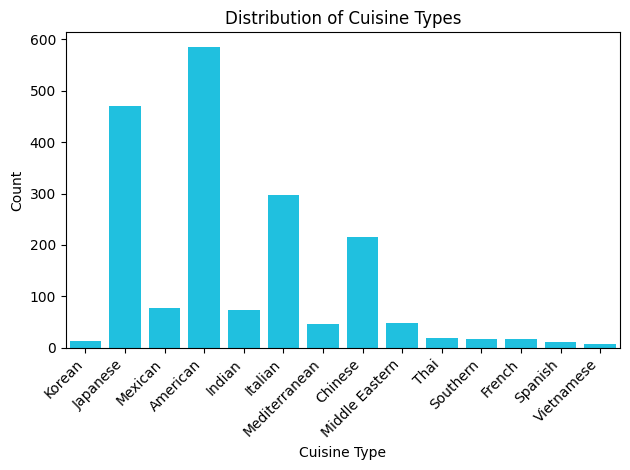

In [8]:
sns.countplot(x='cuisine_type', data=df, color="#00d5ff92")
plt.title('Distribution of Cuisine Types')
plt.xlabel('Cuisine Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

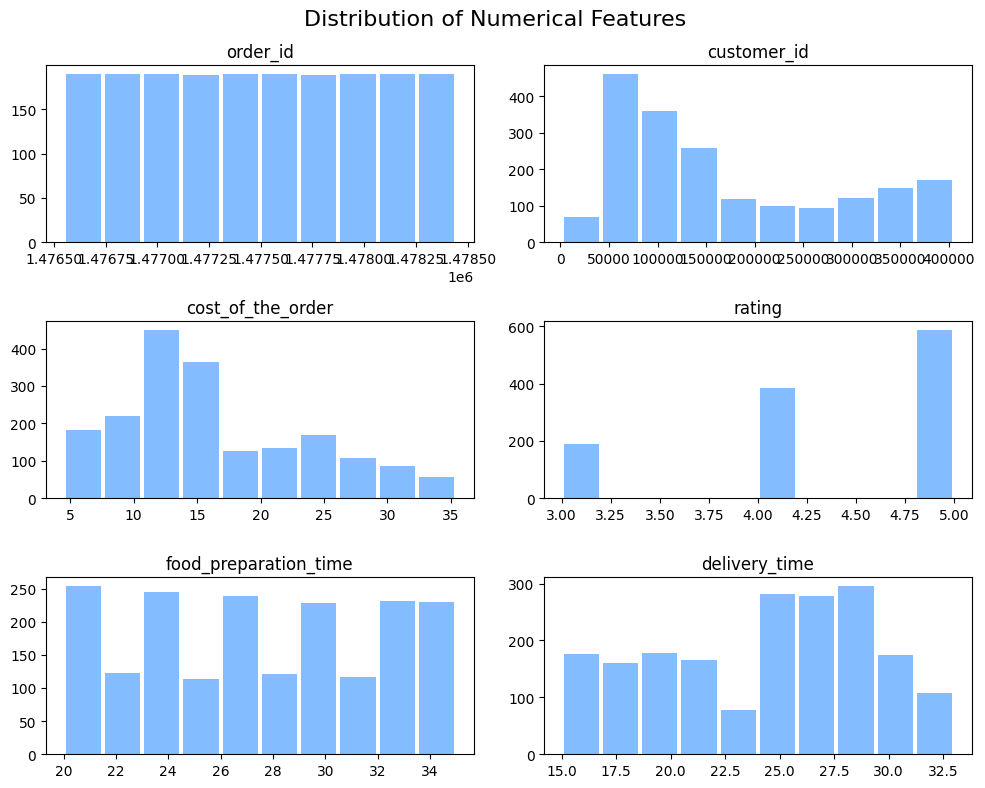

In [9]:
df.hist(figsize=(10, 8), grid=False, bins=10, color="#288cff92", zorder=2, rwidth=0.9)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

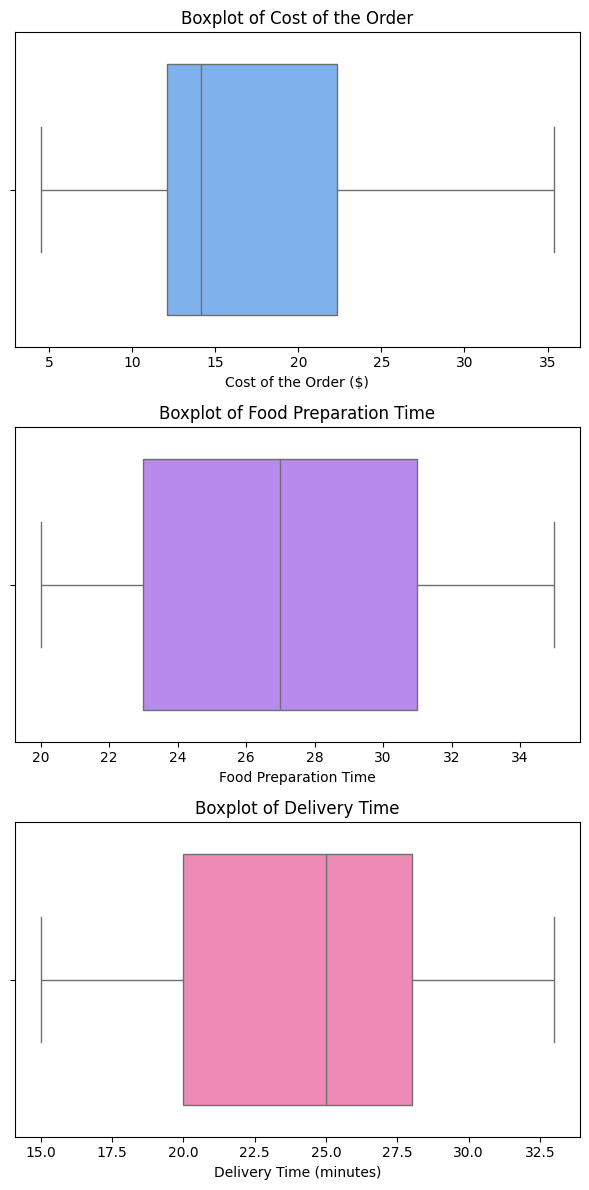

In [10]:
figure, axes = plt.subplots(3, 1, figsize=(6,12))
sns.boxplot(x=df['cost_of_the_order'], color="#6db1fe92", ax=axes[0])
axes[0].set_title('Boxplot of Cost of the Order')
axes[0].set_xlabel('Cost of the Order ($)')
sns.boxplot(x=df['food_preparation_time'], color="#b979fd92", ax=axes[1])
axes[1].set_title('Boxplot of Food Preparation Time')
axes[1].set_xlabel('Food Preparation Time')
sns.boxplot(x=df['delivery_time'], color="#fd79b492", ax=axes[2])
axes[2].set_title('Boxplot of Delivery Time')
axes[2].set_xlabel('Delivery Time (minutes)')
plt.tight_layout()
plt.show()

# Right skewed distribution of cost of the order with some outliers.

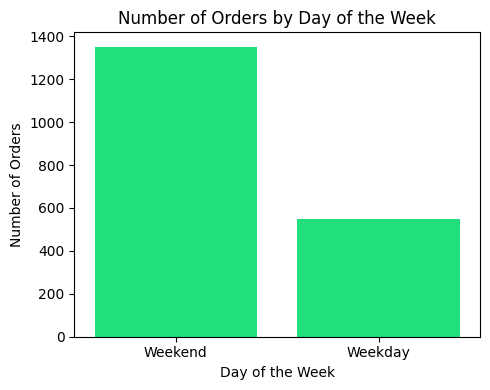

Number of orders on weekdays: 547
Number of orders on weekends: 1351


In [11]:
plt.figure(figsize=(5, 4))
sns.countplot(x='day_of_the_week', data=df, color="#00ff7b92")
plt.title('Number of Orders by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()  

print("Number of orders on weekdays:", df[df['day_of_the_week']=='Weekday'].shape[0])
print("Number of orders on weekends:", df[df['day_of_the_week']=='Weekend'].shape[0])

## 5. Bivariate Analysis

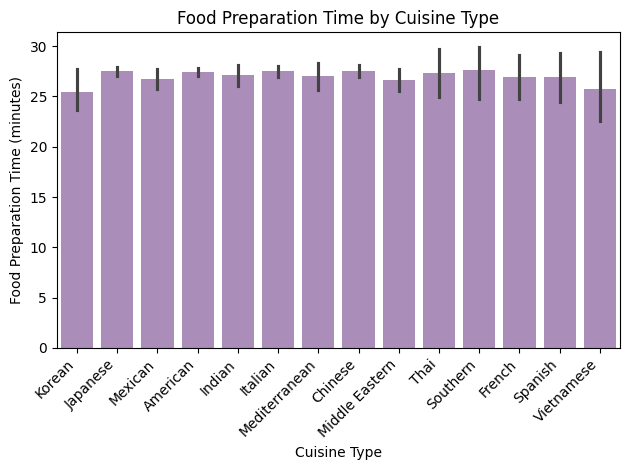

<Axes: xlabel='cost_of_the_order', ylabel='Count'>

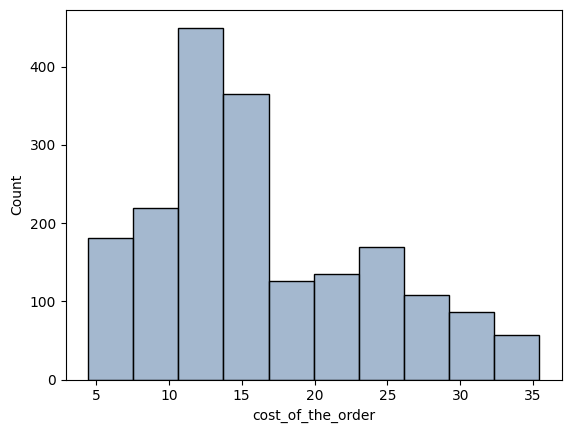

In [12]:
sns.barplot(x='cuisine_type', y='food_preparation_time', data=df, color="#ac86bf92")
plt.title('Food Preparation Time by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

sns.histplot(x='cost_of_the_order', data=df, color="#86a1bf93", bins=10)

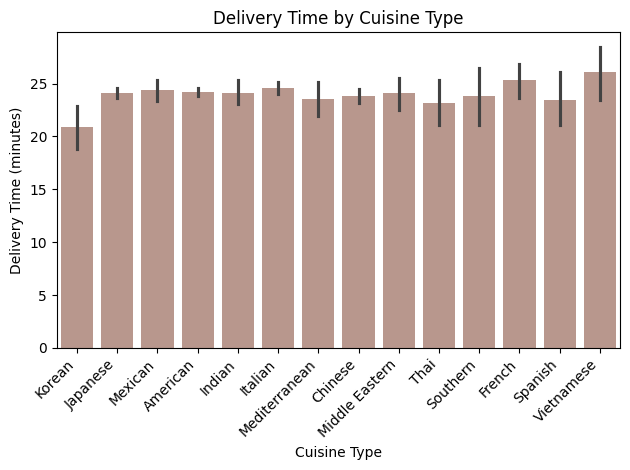

Cuisine types with the longest average delivery times: 26.142857142857142
Cuisine types with the shortest average delivery times: 20.923076923076923


In [13]:
sns.barplot(x='cuisine_type', y='delivery_time', data=df, color="#bf938692")
plt.title('Delivery Time by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Delivery Time (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

cuisine_delivery_time_max = df.groupby('cuisine_type')['delivery_time'].mean().sort_values(ascending=False)
print("Cuisine types with the longest average delivery times:", cuisine_delivery_time_max.iloc[0])

cuisine_delivery_time_min = df.groupby('cuisine_type')['delivery_time'].mean().sort_values(ascending=True)
print("Cuisine types with the shortest average delivery times:", cuisine_delivery_time_min.iloc[0]) 


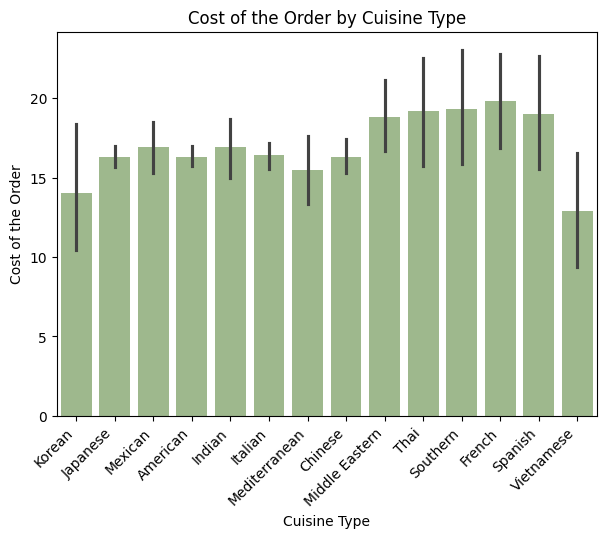

Most expensive cuisine types on average: 19.79388888888889
Cheapest cuisine types on average: 12.882857142857144


In [14]:
sns.barplot(x=df['cuisine_type'], y=df['cost_of_the_order'], data=df, color="#9cbf86ff")
plt.title('Cost of the Order by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Cost of the Order')
plt.tight_layout()
plt.xticks(rotation=45, ha='right')
plt.show()

expensive_cuisines = df.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values(ascending=False)
print("Most expensive cuisine types on average:", expensive_cuisines.iloc[0])

cheapest_cuisines = df.groupby('cuisine_type')['cost_of_the_order'].mean().sort_values(ascending=True)
print("Cheapest cuisine types on average:", cheapest_cuisines.iloc[0])

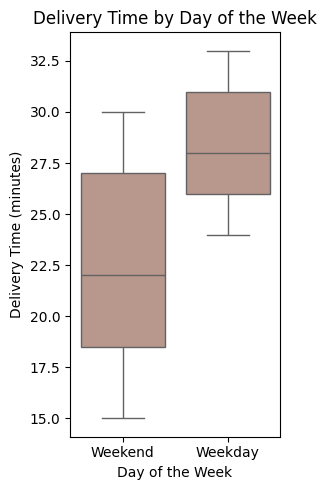

In [15]:
plt.figure(figsize=(3, 5))
sns.boxplot(x='day_of_the_week', y='delivery_time', data=df, color="#bf938692")
plt.title('Delivery Time by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Delivery Time (minutes)')
plt.tight_layout()
plt.show()

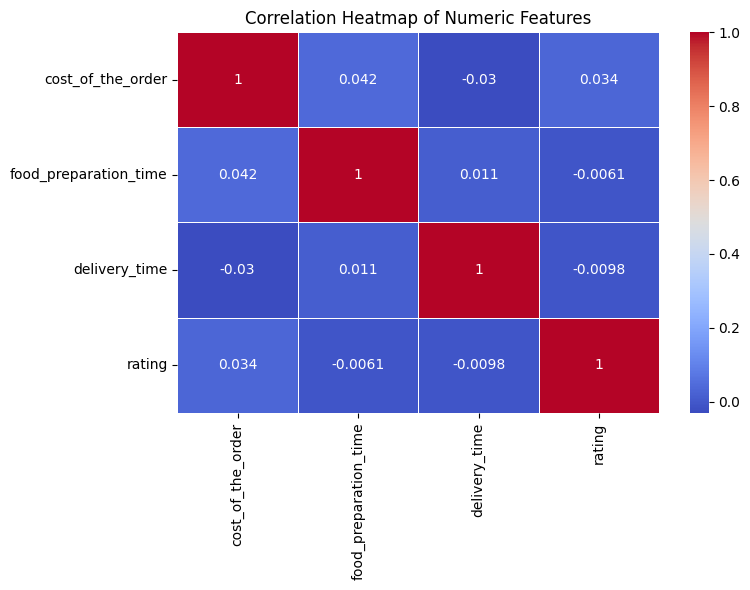

In [16]:
plt.figure(figsize=(8,6))
numeric_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']

sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()


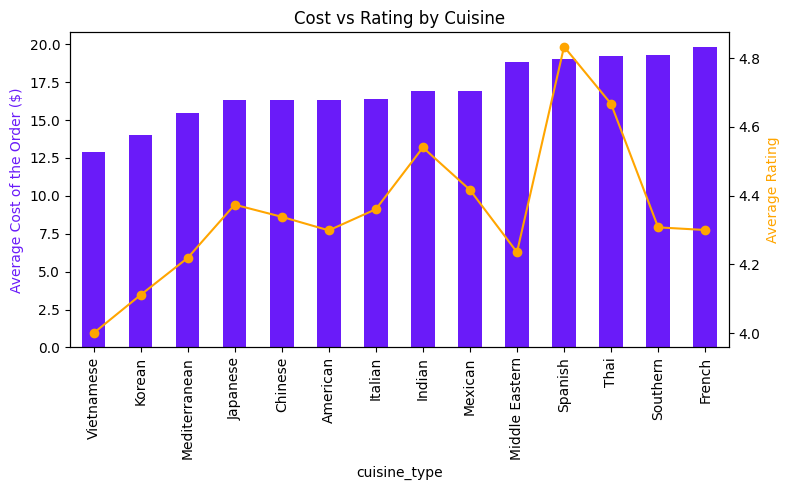

In [17]:
grouped = df.groupby('cuisine_type')[['cost_of_the_order', 'rating']].mean().sort_values(by='cost_of_the_order')

ax = grouped['cost_of_the_order'].plot(kind='bar', color='#6a1bf9', figsize=(8,5))
ax2 = ax.twinx()

grouped['rating'].plot(kind='line', color='orange', marker='o', ax=ax2)

plt.xticks(rotation=45)
plt.title('Cost vs Rating by Cuisine')
plt.xlabel('Cuisine Type')
ax.set_ylabel('Average Cost of the Order ($)', color='#6a1bf9')
ax2.set_ylabel('Average Rating', color='orange')
plt.tight_layout()
plt.show()

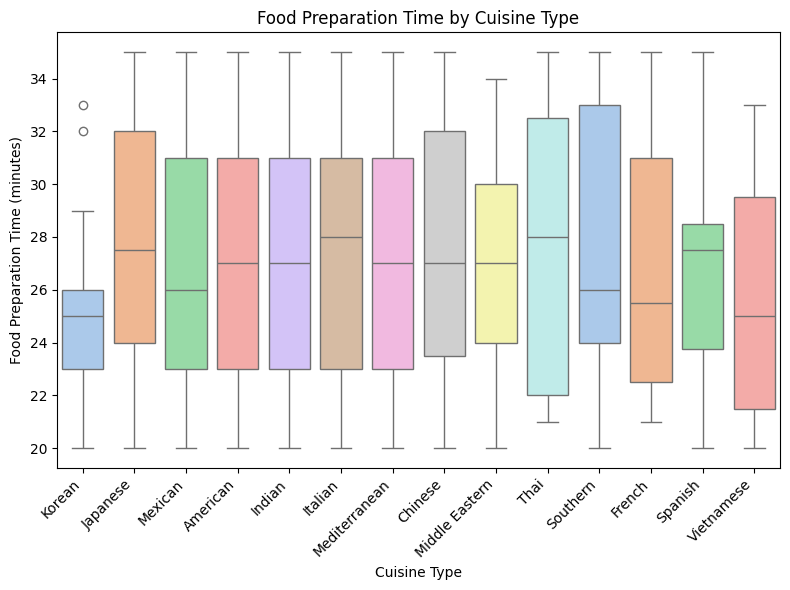

In [18]:
plt.figure(figsize=(8,6))
sns.boxplot(x='cuisine_type', y='food_preparation_time', data=df, hue='cuisine_type', palette='pastel', legend=False)
plt.title('Food Preparation Time by Cuisine Type')
plt.xlabel('Cuisine Type')
plt.ylabel('Food Preparation Time (minutes)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()  
plt.show()

## 6. Business Questions

Answering FoodHub's operational questions directly: top customers, top restaurants,
weekend cuisine preferences, and order-value/time thresholds.

In [19]:
list(df.columns)
top_3_customers = df['customer_id'].value_counts().head(3).reset_index()
top_3_customers.columns = ['customer_id', 'number_of_orders']
print("Top 3 customers by number of orders:", '\n', top_3_customers)

Top 3 customers by number of orders: 
    customer_id  number_of_orders
0        52832                13
1        47440                10
2        83287                 9


In [20]:
shortest_delivery_time = df.groupby('restaurant_name')['delivery_time'].mean().sort_values(ascending=True)
print("Restaurant with the shortest average delivery time:", shortest_delivery_time.index[0], "with", shortest_delivery_time.iloc[0], "minutes")

longest_delivery_time = df.groupby('restaurant_name')['delivery_time'].mean().sort_values(ascending=False)
print("Restaurant with the longest average delivery time:", longest_delivery_time.index[0], "with", longest_delivery_time.iloc[0], "minutes")

Restaurant with the shortest average delivery time: Gaia Italian Cafe with 15.0 minutes
Restaurant with the longest average delivery time: Sarabeth's West with 33.0 minutes


In [21]:
best_restaurant = df.groupby('restaurant_name')['rating'].mean().sort_values(ascending=False)
print("Restaurant with the best average rating:", best_restaurant.index[0], "with", best_restaurant.iloc[0], "rating")

worst_restaurant = df.groupby('restaurant_name')['rating'].mean().sort_values(ascending=True)
print("Restaurant with the worst average rating:", worst_restaurant.index[0], "with", worst_restaurant.iloc[0], "rating")

Restaurant with the best average rating: 'wichcraft with 5.0 rating
Restaurant with the worst average rating: Sarabeth's West with 3.0 rating


Top 5 restaurants by number of orders: restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64


<Figure size 500x400 with 0 Axes>

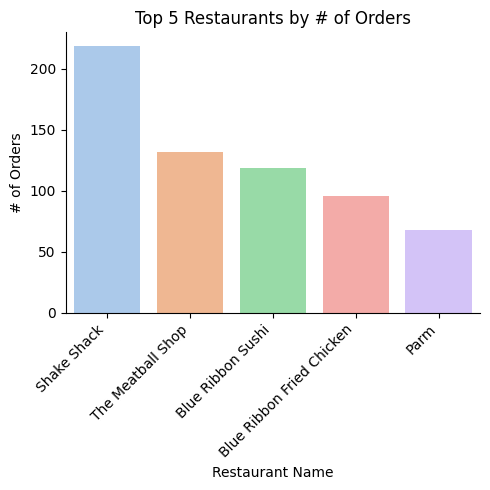

In [22]:
# Write the code here
plt.figure(figsize=(5, 4))
top_5_restaurants = df['restaurant_name'].value_counts().head(5)
print("Top 5 restaurants by number of orders:", top_5_restaurants)
sns.catplot(kind='bar', x=top_5_restaurants.index, y=top_5_restaurants.values,
            hue=top_5_restaurants.index, palette='pastel', legend=False)
plt.title('Top 5 Restaurants by # of Orders')
plt.xlabel('Restaurant Name')
plt.ylabel('# of Orders')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Most popular cuisine types on weekends: cuisine_type
American    415
Name: count, dtype: int64


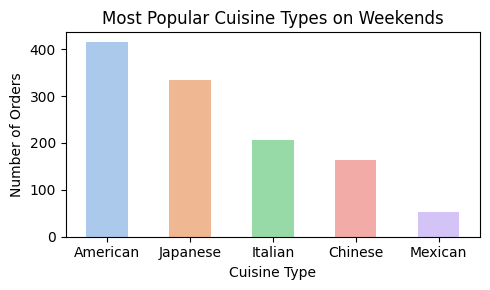

In [23]:
plt.figure(figsize=(5, 3))
popular_cuisines_on_weekends = df[df['day_of_the_week']=='Weekend']['cuisine_type'].value_counts().head(5)
print("Most popular cuisine types on weekends:", popular_cuisines_on_weekends[:1])
sns.barplot(x=popular_cuisines_on_weekends.index, y=popular_cuisines_on_weekends.values, 
            hue=popular_cuisines_on_weekends.index, palette='pastel', width=0.5)
plt.title('Most Popular Cuisine Types on Weekends')
plt.xlabel('Cuisine Type')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

In [24]:
orders_above_20 = (df['cost_of_the_order'] > 20).sum()
print(f"Number of orders above $20: {orders_above_20}")
total_orders = len(df)
print(f"Total number of orders: {total_orders}")
percentage_above_20 = (orders_above_20 / total_orders) * 100
print(f"Percentage of orders above $20: {percentage_above_20:.2f}%")

Number of orders above $20: 555
Total number of orders: 1898
Percentage of orders above $20: 29.24%


In [25]:
mean = df['delivery_time'].mean()
print(f"Mean delivery time: {mean} minutes")

Mean delivery time: 24.161749209694417 minutes


In [26]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
orders_above_60 = (df['total_time'] > 60).sum()
total_orders_count = len(df)
percentage_above_60 = (orders_above_60 / total_orders_count) * 100

print(f"Number of orders taking more than 60 minutes: {orders_above_60}")
print(f"Percentage of orders taking more than 60 minutes: {percentage_above_60:.2f}%")

Number of orders taking more than 60 minutes: 200
Percentage of orders taking more than 60 minutes: 10.54%


Mean delivery time on Weekdays: 28.34 minutes
Mean delivery time on Weekends: 22.47 minutes
Difference: 5.87 minutes


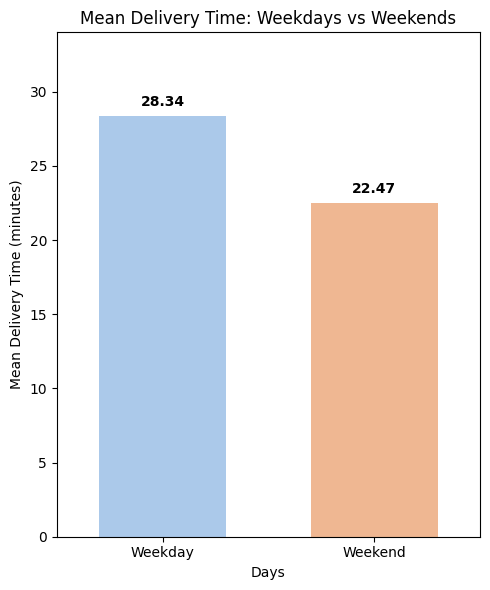

In [27]:
weekday_delivery_time = df[df['day_of_the_week'] == 'Weekday']['delivery_time'].mean()
weekend_delivery_time = df[df['day_of_the_week'] == 'Weekend']['delivery_time'].mean()

print(f"Mean delivery time on Weekdays: {weekday_delivery_time:.2f} minutes")
print(f"Mean delivery time on Weekends: {weekend_delivery_time:.2f} minutes")
print(f"Difference: {abs(weekday_delivery_time - weekend_delivery_time):.2f} minutes")

# Visualize the comparison
plt.figure(figsize=(5, 6))
day_type = ['Weekday', 'Weekend']
mean_times = [weekday_delivery_time, weekend_delivery_time]
sns.barplot(x=day_type, y=mean_times, hue=day_type, width=0.6, palette='pastel', legend=False)
plt.title('Mean Delivery Time: Weekdays vs Weekends')
plt.xlabel('Days')
plt.ylabel('Mean Delivery Time (minutes)')
plt.ylim(0, max(mean_times) * 1.2)
for i, v in enumerate(mean_times):
    plt.text(i, v + 0.5, f'{v:.2f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Promotional Offer & Revenue Analysis

FoodHub wants to run a promotional offer for restaurants that are both popular and
highly rated (more than 50 ratings and an average rating above 4), and wants to
understand how much revenue each restaurant generates under its tiered commission
structure (25% on orders above \$20, 15% on orders between \$5 and \$20, no
commission below \$5).

In [28]:
df_cleaned = df.dropna(subset=['rating'], axis=0)
restaurant_stats = df_cleaned.groupby('restaurant_name')['rating'].agg(['count', 'mean'])
eligible_restaurants = restaurant_stats[(restaurant_stats['count'] > 50) & (restaurant_stats['mean'] > 4)].sort_values(by='count', ascending=False).reset_index()
print("Restaurants eligible for the offer:")
print(eligible_restaurants)

Restaurants eligible for the offer:
             restaurant_name  count      mean
0                Shake Shack    133  4.278195
1          The Meatball Shop     84  4.511905
2          Blue Ribbon Sushi     73  4.219178
3  Blue Ribbon Fried Chicken     64  4.328125


In [29]:
def revenue_generated_by_restaurant(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

df['estimated_revenue'] = df['cost_of_the_order'].apply(revenue_generated_by_restaurant)
revenue_by_restaurant = df.groupby('restaurant_name')['estimated_revenue'].sum().sort_values(ascending=False)
print("Total revenue generated by each restaurant:", revenue_by_restaurant) 

Total revenue generated by each restaurant: restaurant_name
Shake Shack                   703.6070
The Meatball Shop             419.8285
Blue Ribbon Sushi             360.4605
Blue Ribbon Fried Chicken     340.2035
Parm                          218.5570
                                ...   
Market Table                    1.0185
Wa Jeal                         1.0110
Cipriani Le Specialita          0.8880
Big Wong Restaurant _¤¾Ñ¼      0.8880
Hunan Manor                     0.8580
Name: estimated_revenue, Length: 178, dtype: float64


### Conclusions:
*  Majority of orders fall within the moderate price range ($12 - $22). May indicate that customers prefer resonably priced meals over high cost options. 
* Food preparation time (avg = 27.4 min) is usually more than the time needed for delivery (avg = 24.2 min), thereby suggesting importance of restaurant efficiancy on total order time than the delivery time. 
* The correlation between the cost, preparation time, delivery time, and rating (correlation coefficients close to 0). This indicates that customer satistaction isn't alone driven by these factors. 
* Customers tend to order significantly more on the weekends (no. of orders = 1351) than on the weekdays (no. of orders = 547). 
* Delivery time on a weekday (avg = 28.34 min) is much higher than on the weekends (avg = 22.5 min), suggesting the external factors, such as, rush hour and traffic, etc. plays a role too. 
* Certain cuisines and restaurants (i.e. American cuisine: Shake shack) receive higher order counts, showing customer preferences.
* Similarly, some cuisines with higher average costs tend to have slightly higher ratings, suggesting that customers may associate higher-priced meals with better perceived quality. However, this relationship is not consistent across all cuisines. Additionally, the presence of a significant number of “Not given” ratings may introduce bias in the analysis of customer satisfaction.
* A small number of restaurants (e.g., Shake Shack, The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken) meet the criteria of having both a high number of ratings (>50) and an average rating above 4. This indicates that only a few restaurants consistently deliver high-quality service at scale, making them strong candidates for promotional offers.
* Revenue analysis shows that a few top-performing restaurants (such as Shake Shack and The Meatball Shop) contribute disproportionately to total revenue, indicating that the company’s earnings are concentrated among a small group of high-performing partners.

### Recommendations:

*  Promote mid-range pricing - Since most orders are concentrated within the $12–$22 range, the company should encourage restaurants to offer competitively priced meals within the band to maximize order volume and customer retention.
* Focus on restaurant efficiency - As food preparation time contributes more to total order time than delivery, the company should work with restaurants to optimize kitchen operations, reduce preparation delays, and improve overall service speed, while maintaining the qualtiy.
* Focus beyond time and cost to improve ratings - Given the weak correlation between operational metrics and ratings (biased), restaurants should focus on food quality, packaging, and overall customer experience to enhance customer satisfaction.
* Leverage weekend demand through targeted promotions - Since order volume is significantly higher on weekends, the company can introduce weekend-specific deal to maximize revenue.
* Optimize weekday delivery performance - Higher weekday delivery times suggest traffic-related inefficiencies. The company should focus on route optimization, increase delivery personnel during peak hours, or implement dynamic delivery strategies depending on the hour.
* Capitalize on popular cuisines and restaurants - High-demand cuisines and top-performing restaurants (e.g., Shake Shack) should be given greater visibility through featured listings, advertisements, or priority placement on the platform.
* Refine pricing and positioning strategies for premium cuisines - As higher-cost cuisines tend to have slightly better ratings, the company can position these as premium offerings while ensuring consistent quality to justify the price.
* Improve rating system reliability - The presence of many “Not given” ratings suggests incomplete feedback. The platform should encourage users to leave ratings through incentives like point-based system or simplified feedback mechanisms to reduce bias.
* Strengthen partnerships with top revenue-generating restaurants - Since a large portion of revenue comes from a few key restaurants, the company should build strategic partnerships with these high-performing vendors to ensure sustained revenue growth.